# Ejercicio a)

Se pide crear un script en python que dada la trayectoría ground-truth (timestamp, x,
y, z, qw, qx, qy, qz) (primeras 8 columnas del archivo mav0/state_groundtruth_estimate0/data
.csv) genere el camino ground-truth de la cámara izquierda, esté debe estar dado en el sistema de
coordenadas de la cámara izquierda inicial. Para esto deberá utilizar las transformaciones provistas
en el dataset.

* Lo pedido es un proceso similar al del ejercicio 4.
* Allí, podíamos obtener fácilmente todos los ${}^W \xi_{C_i}$ (la primera pregunta)}
* y en base a eso, obtener los ${}^W \xi_{B_i}$
* En este ejercicio, el objetivo es ${}^{C_0} \xi_{C_i}$

En este ejercicio, ya tenemos los ${}^W \xi_{B_i}$, nos lo dice el propio enunciado.

Por otro lado, tenemos la transformación ${}^B \xi_{C}$ en el archivo `./cam0/data/sensor.yaml`. (Vamos a tomar a $C$ como la cámara izquierda, la camara derecha no debería mecionarse en principio)

```py
# ./cam0/data/sensor.yaml
T_BS:
  cols: 4
  rows: 4
  data: [0.0148655429818, -0.999880929698, 0.00414029679422, -0.0216401454975,
         0.999557249008, 0.0149672133247, 0.025715529948, -0.064676986768,
        -0.0257744366974, 0.00375618835797, 0.999660727178, 0.00981073058949,
         0.0, 0.0, 0.0, 1.0]
```

Así, tenemos:

$$
{}^B \xi_{C}
=
\begin{bmatrix}
0.0148655429818 & -0.999880929698 & 0.00414029679422 & -0.0216401454975 \\
0.999557249008 & 0.0149672133247 & 0.025715529948 & -0.064676986768 \\
-0.0257744366974 & 0.00375618835797 & 0.999660727178 & 0.00981073058949 \\
0.0 & 0.0 & 0.0 & 1.0
\end{bmatrix}
$$

Razonando de manera similar al ejercicio 4, tenemos,

$$
{}^W \xi_{C_i}
=
{}^W \xi_{B_i} \cdot {}^{B_i} \xi_{C_i}
=
{}^W \xi_{B_i} \cdot {}^B \xi_{C}
$$

Se nos pide expresamente en el enunciado:

> Genere el camino ground-truth de la cámara izquierda, **esté debe estar dado en el sistema de coordenadas de la cámara izquierda inicial.**

Por lo tanto, deberíamos obtener

$$
{}^{C_0} \xi_{C_i} \forall i \in N
$$

Notemos que

$$
{}^{C_0} \xi_{C_i}
=
{}^{C_0} \xi_{W} \cdot {}^{W} \xi_{C_i}
=
({}^{W} \xi_{C_0})^{-1} \cdot {}^{W} \xi_{C_i}
$$

## Desarrollo

In [86]:
import csv
import yaml
import numpy as np
from transforms3d.quaternions import quat2mat, mat2quat

Vamos a llamar `T_BS` a ${}^{B} \xi_{C}$, por convención del dataset y por facilidad

In [87]:
with open('mav0/cam0/sensor.yaml', 'r') as f:
    cam0YAML = yaml.safe_load(f)

T_BS_data = cam0YAML['T_BS']['data']
T_BS = np.array(T_BS_data).reshape(4, 4)

print(T_BS)

[[ 0.0149 -0.9999  0.0041 -0.0216]
 [ 0.9996  0.015   0.0257 -0.0647]
 [-0.0258  0.0038  0.9997  0.0098]
 [ 0.      0.      0.      1.    ]]


In [88]:
gt_path = 'mav0/state_groundtruth_estimate0/data.csv'
ground_truth = []

with open(gt_path, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)
    for row in reader:
        tmstmp = int(row[0])
        x, y, z =   float(row[1]),\
                    float(row[2]), \
                    float(row[3])
        qw, qx, qy, qz = float(row[4]), float(row[5]), float(row[6]), float(row[7])

        R_i = quat2mat([qw, qx, qy, qz])
        t_i = np.array([x, y, z])

        Bi_to_W = np.eye(4)
        Bi_to_W[:3, :3] = R_i
        Bi_to_W[:3, 3] = t_i

        ground_truth.append((tmstmp, Bi_to_W))

print(f"Se leyeron {len(ground_truth)} poses")

        


Se leyeron 36382 poses


In [89]:
camera_path_world = []

for tmstmp, Bi_to_W in ground_truth:
    Ci_to_W = Bi_to_W @ T_BS
    camera_path_world.append((tmstmp, Ci_to_W))

In [90]:
_, C0_to_W = camera_path_world[0]
C0_to_W_inv = np.linalg.inv(C0_to_W)

In [91]:
camera_path_c0 = []

for tmstmp, Ci_to_W in camera_path_world:
    Ci_to_C0 = C0_to_W_inv @ Ci_to_W
    camera_path_c0.append((tmstmp, Ci_to_C0))

In [92]:
# print(camera_path_c0)

In [93]:
np.set_printoptions(precision=4, suppress=True)

for tmstmp, ci_to_c0 in camera_path_c0[:5]:
    print(f"timestamp: {tmstmp}")
    print(ci_to_c0)
    print("-" * 40)

timestamp: 1403636580838555648
[[ 1. -0.  0.  0.]
 [ 0.  1. -0.  0.]
 [ 0. -0.  1. -0.]
 [ 0.  0.  0.  1.]]
----------------------------------------
timestamp: 1403636580843555328
[[ 1.      0.0006  0.0011  0.0001]
 [-0.0006  1.     -0.0015 -0.0037]
 [-0.0011  0.0015  1.     -0.0014]
 [ 0.      0.      0.      1.    ]]
----------------------------------------
timestamp: 1403636580848555520
[[ 1.      0.0012  0.0022  0.0002]
 [-0.0012  1.     -0.0031 -0.0074]
 [-0.0022  0.0031  1.     -0.0028]
 [ 0.      0.      0.      1.    ]]
----------------------------------------
timestamp: 1403636580853555456
[[ 1.      0.0019  0.0033  0.0004]
 [-0.0019  1.     -0.0047 -0.0112]
 [-0.0033  0.0047  1.     -0.0041]
 [ 0.      0.      0.      1.    ]]
----------------------------------------
timestamp: 1403636580858555648
[[ 1.      0.0026  0.0045  0.0005]
 [-0.0026  1.     -0.0063 -0.0149]
 [-0.0046  0.0063  1.     -0.0055]
 [ 0.      0.      0.      1.    ]]
----------------------------------------

# Ejercicio b)

In [94]:
def tmstmp_to_scnd(tmpstmp_ns):
    scnds = tmpstmp_ns // 10**9
    nanos = tmpstmp_ns % 10**9
    return f'{scnds}.{nanos:09d}'

out_rows = []

for tmstmp, Ci_to_C0 in camera_path_c0:
    R_i = Ci_to_C0[:3, :3]
    t_i = Ci_to_C0[:3, 3]
    qw, qx, qy, qz = mat2quat(R_i)

    ts_str = tmstmp_to_scnd(tmstmp)
    out_rows.append([ts_str, t_i[0], t_i[1], t_i[2], qw, qx, qy, qz])

with open('camera_groundtruth_c0.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['#timestamp', 'x', 'y', 'z', 'qw', 'qx', 'qy', 'qz'])
    writer.writerows(out_rows)

with open(gt_path, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)
    print(header[:8])
    for i, row in enumerate(reader):
        if i >= 5:
            break
        print(row[:8])

print('\n\n')

for row in out_rows[:5]:
    ts, *vals = row
    print([ts] + [f'{v:.6f}' for v in vals])


['#timestamp', ' p_RS_R_x [m]', ' p_RS_R_y [m]', ' p_RS_R_z [m]', ' q_RS_w []', ' q_RS_x []', ' q_RS_y []', ' q_RS_z []']
['1403636580838555648', '4.688319', '-1.786938', '0.783338', '0.534108', '-0.153029', '-0.827383', '-0.082152']
['1403636580843555328', '4.688177', '-1.786770', '0.787350', '0.534640', '-0.152990', '-0.826976', '-0.082863']
['1403636580848555520', '4.688028', '-1.786598', '0.791382', '0.535178', '-0.152945', '-0.826562', '-0.083605']
['1403636580853555456', '4.687878', '-1.786421', '0.795429', '0.535715', '-0.152884', '-0.826146', '-0.084391']
['1403636580858555648', '4.687727', '-1.786240', '0.799484', '0.536244', '-0.152821', '-0.825731', '-0.085213']



['1403636580.838555648', '0.000000', '0.000000', '-0.000000', '1.000000', '-0.000000', '-0.000000', '0.000000']
['1403636580.843555328', '0.000114', '-0.003709', '-0.001380', '1.000000', '0.000769', '0.000530', '-0.000288']
['1403636580.848555520', '0.000230', '-0.007437', '-0.002757', '0.999998', '0.001553', '0.0

# Ejercicio c)

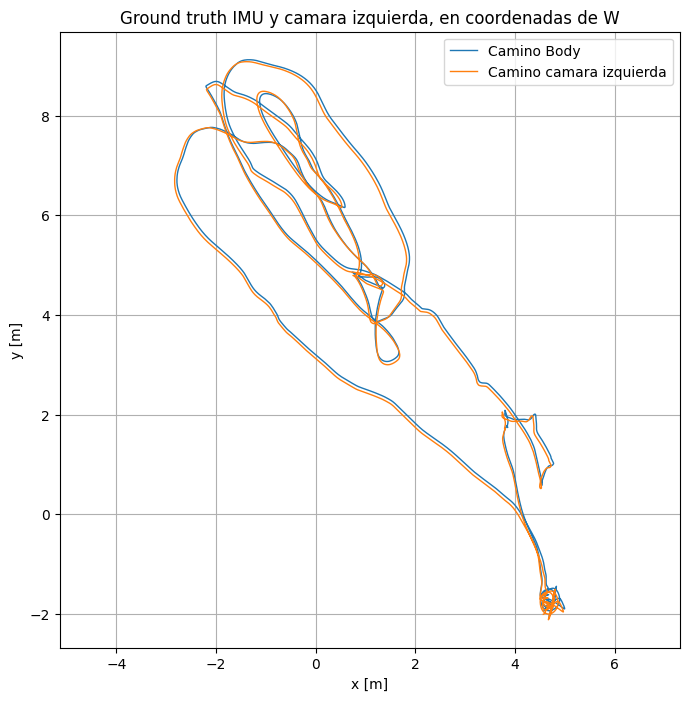

In [ ]:
import matplotlib.pyplot as plt

imu_xs = [Bi_to_W[0, 3] for _, Bi_to_W in ground_truth]
imu_ys = [Bi_to_W[1, 3] for _, Bi_to_W in ground_truth]

cam_xs = [Ci_to_W[0, 3] for _, Ci_to_W in camera_path_world]
cam_ys = [Ci_to_W[1, 3] for _, Ci_to_W in camera_path_world]

plt.figure(figsize=(8, 8))
plt.plot(imu_xs, imu_ys, label='Camino Body', linewidth=1)
plt.plot(cam_xs, cam_ys, label='Camino camara izquierda', linewidth=1)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Ground truth IMU y camara izquierda, en coordenadas de W')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.savefig('ej5-c-robo.png', dpi=150, bbox_inches='tight')
plt.show()
